# A Hands-On Introduction to the Persistent Homology Pipeline 

#### Author: Siddharth Setlur 

Please complete the `## FINISH_ME ##` sections of code in the notebook; then run the code, saving the output.
**All problems are due for hand-in as the first part of Homework 3, by 9:30am on Friday 20 March.**

| <p align='left'> Problem  (by Section number)                | <p align='left'> Marks possible |  <p align='left'> Marks awarded |
| ------------------------------------- | --- | --- |
| <p align='left'> 1. Rips complex animation  | <p align='left'> 1 | |
| <p align='left'> 2. Creating a persistence diagram  | <p align='left'> 1 | |
| <p align='left'> 3. Defining a TDA pipeline | <p align='left'> 2 | |
| <p align='left'> 4. Some variations of the single circle | <p align='left'> 2 | |
| <p align='left'> 5. Adding (and removing) noise  | <p align='left'> 1 |  |
| <p align='left'> **Total** | <p align='left'> max **7** | |

The first thing we need to do add Gudhi to our agq conda environment. Gudhi is a TDA package to compute persistence (among other things). We will also use shapely (a Python library for geometric operations and manipulating 2D shapes).

If you've opened this jupyter notebook in the agq-env enviroment, run the following:

(If this fails, run ```conda install gudhi shapely``` in your terminal instead, inside the agq-env environment.)

In [1]:
!conda install gudhi shapely -y

Jupyter detected...
3 channel Terms of Service accepted
Retrieving notices: done
Channels:
 - defaults
Platform: win-64
Solving environment: failed



PackagesNotFoundError: The following packages are not available from current channels:

  - gudhi

Current channels:

  - defaults

To search for alternate channels that may provide the conda package you're
looking for, navigate to

    https://anaconda.org

and use the search bar at the top of the page.




For the following import commands, make sure that you've created a ```helper_functions/``` folder inside your working directory, and that this folder contains the ```noisy_circle.py``` and ```density.py``` files.

In [1]:
import gudhi as gd
from matplotlib import pyplot as plt
import numpy as np
from scipy.spatial import distance_matrix
import sys
from helper_functions.noisy_circle import sample_from_circle, sample_from_noisy_circle, plot_density
from helper_functions.density import KDE


Let's start with a toy example. Given a bunch of points sampled uniformly from a circle with some noise, let's construct a Vietoris-Rips complex and then compute the persistence diagram using Gudhi.

Let's sample some points from a circle of radius $1$ using the helper function sample_from_circle

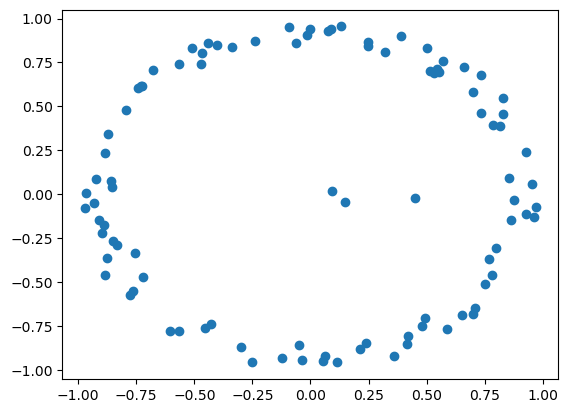

In [2]:
num_points = 100
seed = 3
radius = 1
X = sample_from_circle(num_points=num_points, radius=radius, seed=seed)
plt.figure()
plt.scatter(X[:,0], X[:,1])
plt.show()

Recall from the lecture that the first step in the persistence pipeline is to construct a filtered simplicial complex and that we often do this using a Vietoris-Rips (VR) complex. Gudhi has an inbuilt method to do this!

The max_edge_length just says that we don't consider VR complexes constructed using balls larger than this radius in our filtration. Note that in our case, the complex becomes trivial when we use balls of radius greater than the diameter of the circle, since we would fill in the entire circle then. In practice, when one works with larger datasets, this parameter becomes important because this restricts the size of our complexes (without this we might get complexes with millions of simplices and computation would become infeasible).

In [3]:

rips_comp = gd.RipsComplex(points=X, max_edge_length=2.0)


Gudhi uses a data structure called a simplex tree that makes computing persistence easier. The max dimension parameter tells us that that we only want to consider simplices up to this dimension. In our case, since the circular feature would be captured by $1$-dimensional homology, we only need simplices up to dimension $2$. 

We can then simply call the persistence function on the simplex tree to obtain all the information in a persistence diagram

In [4]:
simplex_tree = rips_comp.create_simplex_tree(max_dimension=2)
pers = simplex_tree.persistence()


## 1. Rips complex animation ##

Let's visualize the evolution of the Rips complex using an animation. Note that computing these visualizations is computationally intensive since we need to iterate over all the simplices in the complex, so we can only do this for data with fewer points. 

Text(-1.3, -1.3, 'Filtration: 1.50\nSimplices: 5626')

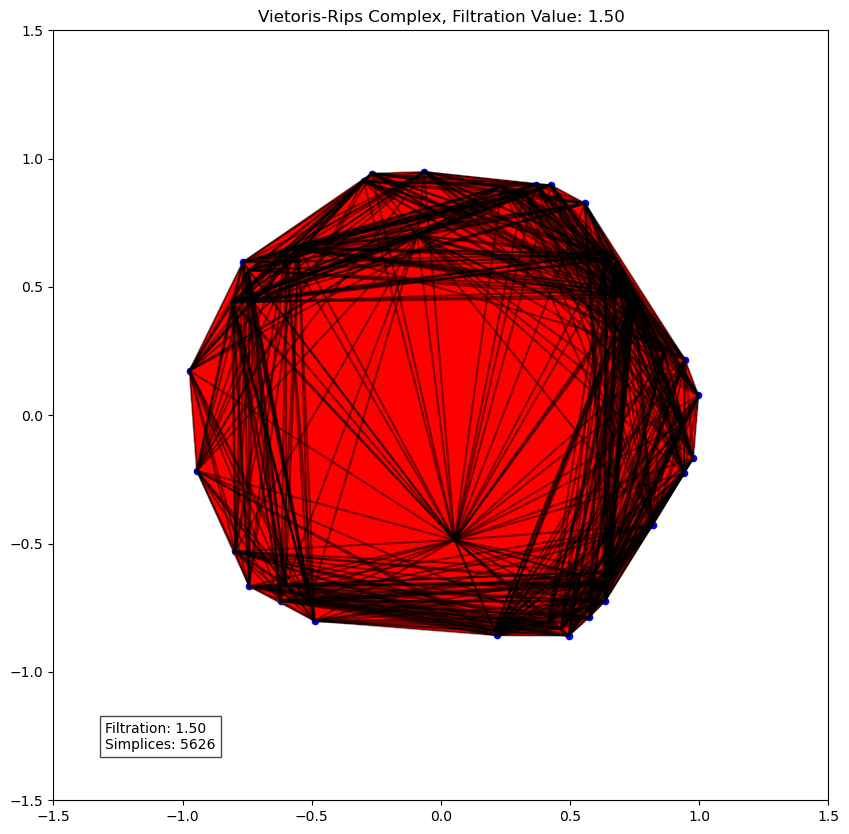

In [26]:
visualization_X = sample_from_circle(num_points=50, radius=1, seed=seed)
rips_comp_visual = gd.RipsComplex(points=visualization_X, max_edge_length=2.0)
simplex_tree_vis = rips_comp_visual.create_simplex_tree(max_dimension=2)
VR_visualization = simplex_tree_vis.copy() #create a copy of the simplex tree, to work with
VR_visualization.prune_above_filtration(0.7) # we can get all simplices born before time 0.7 using this method. 
from IPython.display import display, clear_output
import time

filtration_values = np.linspace(0.0,1.5,20) # we are interested in sampling 20 equidistant filtration values between 0.0 and 1.5
plt.figure(figsize=(10, 10))
for i, filtration in enumerate(filtration_values):
    plt.clf()  # Clear the figure
    plt.scatter(visualization_X[:,0], visualization_X[:,1], c='blue', s=20)
    plt.title(f'Vietoris-Rips Complex, Filtration Value: {filtration:.2f}')
    
    # Create a copy of the simplex tree and prune
    VR_visualization = simplex_tree_vis.copy()
    VR_visualization.prune_above_filtration(filtration)
    num_simplices = VR_visualization.num_simplices()
    
    # Plot edges and triangles
    for simplex in VR_visualization.get_simplices():
        if len(simplex[0]) == 2: #grab the 1 simplices, i.e. edges 
            indices = [simplex[0][0], simplex[0][1]]
            point1 = visualization_X[indices][0]
            point2 = visualization_X[indices][1]
            plt.plot([point1[0], point2[0]], [point1[1], point2[1]], 'k-', alpha=0.5)
        if len(simplex[0]) == 3: # grab the 2 simplices, i.e. triangles.
            indices = [simplex[0][0], simplex[0][1], simplex[0][2]]
            point1 = visualization_X[indices][0]
            point2 = visualization_X[indices][1]
            point3 = visualization_X[indices][2]
            plt.fill([point1[0], point2[0], point3[0]], [point1[1], point2[1], point3[1]], 'r', alpha=0.3)
    
    plt.xlim(-1.5, 1.5)
    plt.ylim(-1.5, 1.5)
    plt.text(-1.3, -1.3, f"Filtration: {filtration:.2f}\nSimplices: {num_simplices}", 
             bbox=dict(facecolor='white', alpha=0.7))
    
    display(plt.gcf())
    clear_output(wait=True)
    time.sleep(0.5)  # Add delay between frames
    
# Display final state
plt.clf()
plt.scatter(visualization_X[:,0], visualization_X[:,1], c='blue', s=20)
plt.title(f'Vietoris-Rips Complex, Filtration Value: {filtration_values[-1]:.2f}')
VR_visualization = simplex_tree_vis.copy()
VR_visualization.prune_above_filtration(filtration_values[-1])
num_simplices = VR_visualization.num_simplices()

for simplex in VR_visualization.get_simplices():
    if len(simplex[0]) == 2:
        indices = [simplex[0][0], simplex[0][1]]
        point1 = visualization_X[indices][0]
        point2 = visualization_X[indices][1]
        plt.plot([point1[0], point2[0]], [point1[1], point2[1]], 'k-', alpha=0.5)
    if len(simplex[0]) == 3:
        indices = [simplex[0][0], simplex[0][1], simplex[0][2]]
        point1 = visualization_X[indices][0]
        point2 = visualization_X[indices][1]
        point3 = visualization_X[indices][2]
        plt.fill([point1[0], point2[0], point3[0]], [point1[1], point2[1], point3[1]], 'r', alpha=0.3)

plt.xlim(-1.5, 1.5)
plt.ylim(-1.5, 1.5)
plt.text(-1.3, -1.3, f"Filtration: {filtration_values[-1]:.2f}\nSimplices: {num_simplices}", 
         bbox=dict(facecolor='white', alpha=0.7))



## 2. Creating a peristence diagram ##

Let's explore the structure of pers, for our original circle X. Each element of pers is a tuple $(\dim, (birth, death))$. The first entry of the tuple being the homological dimension of the feature, i.e. $0$ for $0$ dim features, $1$ for $1$ dim features, etc. The second entry of the tuple is another tuple $(birth, death)$ which has two values corresponding to the birth and death of the feature in question. 

In [36]:
# display the first three elements of pers
pers[0:3]

[(1, (0.2681236671365292, 0.9471778722772286)),
 (1, (0.14814932967612887, 0.1837937699139404)),
 (1, (0.11774161444641258, 0.11932224063084594))]

Let's plot the persistence diagram for $H_1$, i.e. plot the $1$ dimensional features

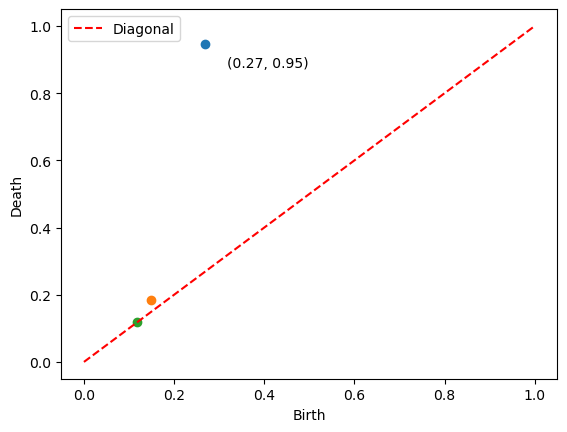

In [42]:
plt.figure()
#scatter plot the $1$-dim features - 
for feature in pers:
    if feature[0]==1:
        plt.scatter(*feature[1])
# plot the diagonal 
plt.plot([0,1],[0,1], color='red', linestyle='dashed', label="Diagonal")
plt.text(pers[0][1][0]+0.05, pers[0][1][1]-0.08, f'({pers[0][1][0]:.2f}, {pers[0][1][1]:.2f})', ha='left', va='bottom')
plt.xlabel('Birth')
plt.ylabel('Death')
plt.legend()
plt.savefig("persistence_diagram_density.jpg")

## 3. Defining a TDA pipeline ##

Let's define a function that implements the entire TDA pipeline, i.e. given a point cloud and the homology dimension, the function shoud output the persistence diagram in that dimension. 

In [40]:
def compute_persistence_diagram(point_cloud, homological_dimension, max_edge_length):
    rips_comp =  gd.RipsComplex(points=point_cloud, max_edge_length=max_edge_length)
    simplex_tree = rips_comp.create_simplex_tree(max_dimension=2)  #I assume?
    pers =  simplex_tree.persistence()
    # Plot the persistence diagram in the given dimension - 
    plt.figure()
    max_feature_dim = 0.0 
    for feature in pers:
        if feature[0] == homological_dimension:
            plt.scatter(*feature[1])
            #The next bit just makes sure that we know where to end the diagonal line, so that the figure looks nice.
            # LEAVE AS IS in the loop 
            if feature[1][0]+feature[1][1]>max_feature_dim:
                max_feature_dim = feature[1][0]+feature[1][1]
    # plot the diagonal 
    plt.plot([0, max_feature_dim], [0, max_feature_dim], color='red', linestyle='dashed', label="Diagonal")
    plt.xlabel('Birth')
    plt.ylabel('Death')
    plt.legend()
    plt.show()

Sometimes functions don't work as expected, so just as a sanity check recompute the persistence diagram for the noisy circle (the variable X) using the function we just wrote and compare it to the result we had earlier

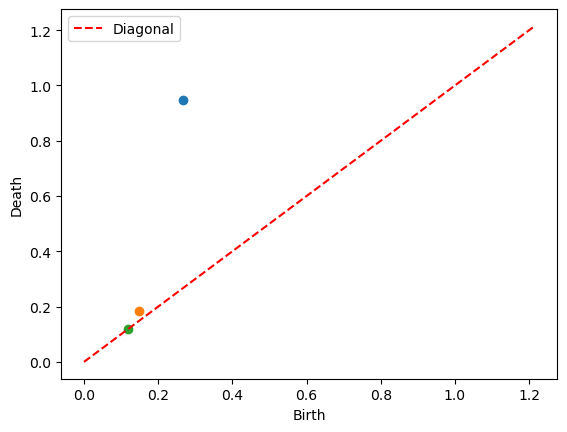

In [41]:
compute_persistence_diagram(X,1,2)

## 4. Some variations of the single circle ##

What do you expect to happen if we sample from a radius of larger circle, e.g. 5? What about the wedge sum of two circles?

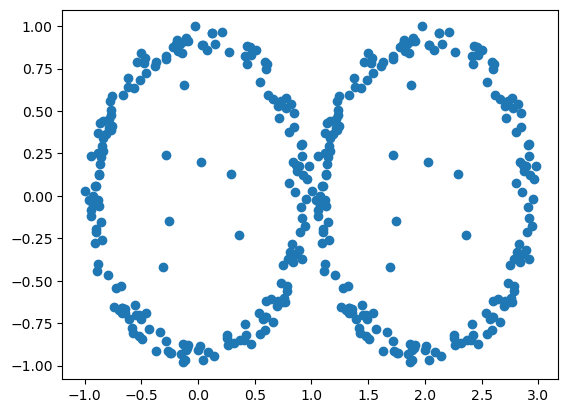

In [44]:
#Generate a circle with 200 points of radius 1
circ1 = sample_from_circle(num_points=200, radius=1, seed=seed)
# generate a second similar circle that's translated by the appproriate amount. Hint - if you have a 2D array X, you can translate it by (a,b) by simply adding np.array([a,b])
circ2 = circ1 + np.array([2,0])
#combine the two circles into a single array 
wedge = np.vstack([circ1,circ2])
#scatter plot the result to visualize 
plt.figure()
plt.scatter(wedge[:,0], wedge[:,1])
plt.show()
plt.show()


Compute and interpret the 1-dimensional persistence diagram. 

IMPORTANT - be careful with the max_edge_length of the rips complex, you have to increase it since the dataset is spread over a larger domain. You can pass ```np.inf``` as the max_edge_length to just compute all simplices (when you pass np.inf, Gudhi computes everything up to radius $\max_{x,y\in X}\{d(x,y)\}$)

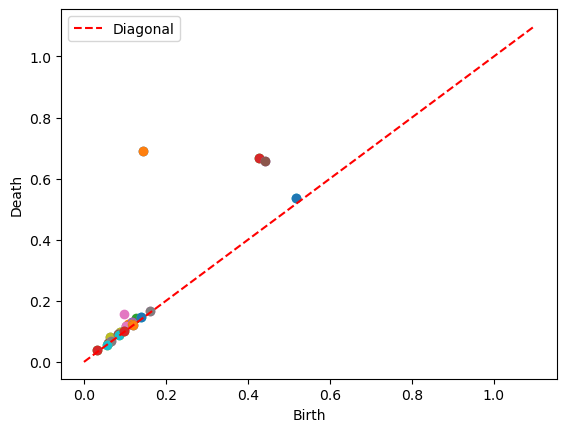

In [46]:
compute_persistence_diagram(wedge,1,np.inf)

What happens with a circle of larger radius? 

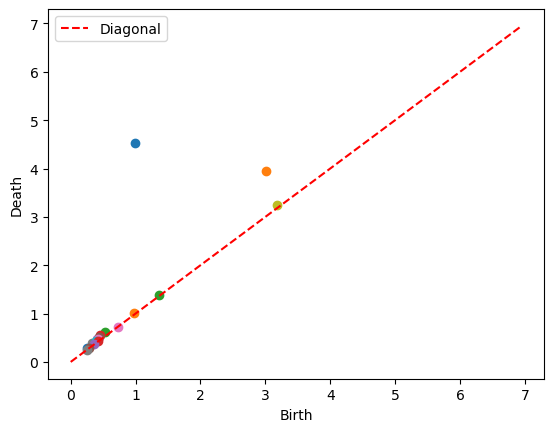

In [47]:
large_circle =  sample_from_circle(num_points=200, radius=5, seed=seed)
compute_persistence_diagram(large_circle, 1, np.inf)

## 5. Adding (and removing) noise ##

Single parameter persistence is stable but not robust! Let's try and see this. What happens to the VR filtration and consequently to the persistence diagram if we add a few noisy points (that are still relatively sparse) to the circle? Can $1$-persistence still discern the signal?

The function sample_from_noisy_circle samples most $80\%$ of its points from the circle and the remaining unifomly distributed. We plot the points and color them using a Gaussian density estimator, this colors points in neighborhoods of high density a darker color and the low density neighborhods a brighter color (the intuition behind this is explained below). The dark color points should be interpreted as the signal, and as we can see we still have the circle as the primary feature.

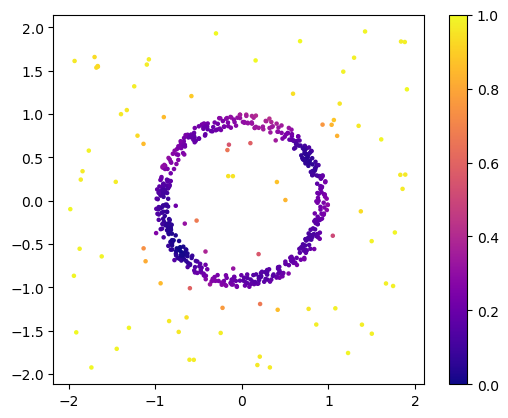

In [48]:

noisy_circle = sample_from_noisy_circle(num_points=500, noise=0.20,radius=1.0, seed=3)
density = np.exp(-1*KDE(bandwidth=0.2).fit(noisy_circle).score_samples(noisy_circle))
# a bit of renormalization
density -= density.min()
density /= density.max()

plt.scatter(noisy_circle[:,0], noisy_circle[:,1], s=5, c=density, cmap="plasma")
plt.gca().set_aspect(1)
plt.colorbar()
plt.show()

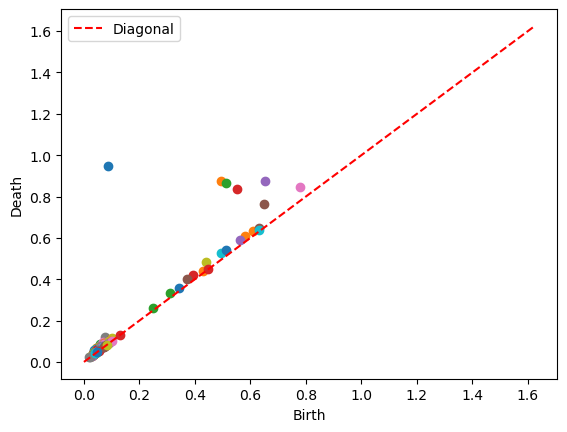

In [49]:
#compute the persistence diagram
compute_persistence_diagram(noisy_circle, 1, np.inf)

Can you remove the noisy points using an appropriate value for the density to recover the signal?

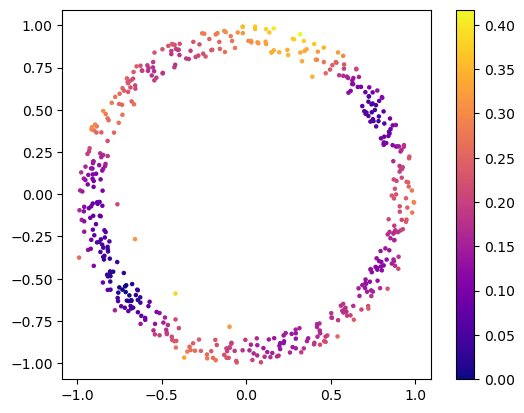

In [50]:
threshold = 0.5
idx = density<threshold # indices where the density value is below the threshold
circle_noise_removed = noisy_circle[idx]
plt.scatter(circle_noise_removed[:,0], circle_noise_removed[:,1], s=5, c=density[idx], cmap="plasma")
plt.gca().set_aspect(1)
plt.colorbar()
plt.show()

Of course in his case, one can visually see that if we just take out the points with value higher than approx $0.9$ we'd recover the signal, but in practice this isn't possible due to dataset size and complexity.
So, is all hope lost? Fortunately not! We can use multiparamter persistence. In this case we can use a density-Rips bifiltration - this just mans that instead of filtering along a single parameter (radius) as we have been doing thus far, we add a second parameter, the density estimate. In general, let $X\subset\mathbb{R}^n$ be a finite metric space and $\gamma: X \to \mathbb{R}$ be a function. For example, $\gamma$ could be the density function above, whose value is high in dense regions of the data and low near sparse regions of the data.  The function-Rips bifiltration is given by 
$$
\textbf{VR}_\gamma(X, a,r) = \textbf{VR}(\gamma^{-1}[a,\infty),r)
$$
where $\textbf{VR}_\gamma(X, a,r)$ denotes the simplicial complex at function value $a$ and VR radius $r$ $(a,r)$. This is simply the VR complex on the points whose $\gamma$-value is higher than $a$ at radius $r$. Inutively, we want points of higher density to appear first so that they spend a longer time in the filtration than lower density point (which are likely noise), so we use a codensity function, whose values are low in regions of high density and high in regions of low density. This means that we need to wait for a much higher value of $a$ until points of low density show up in the filtration.